In [ ]:
import os
import itertools

import networkx as nx

from lipi.refpath.manager import RefPathManager
from lipi.identifiers.ingestion.lipid_maps import ingest_lipid_maps_classes
from lipi.translation.kegg import ingest_kegg_pathway
from lipi.network import load_pathway
from lipi.visualization import plot_pathway_layout, plot_pathway_stats
from lipi.stats import load_stats_from_csv
from lipi.mapping import map_omics_data_to_pathway

In [ ]:
# assumes jupyter notebook server is running at the base of the repo
BASE_DIR = os.path.join(os.getcwd(), "demos", "cptac_4_aml")
REFPATH_FILE = os.path.join(BASE_DIR, "refpath.db")
CACHE_DIR = os.path.join(BASE_DIR, "_cache/")
KEGG_CACHE_FILE = os.path.join(CACHE_DIR, "kegg_cache.pkl")
LMSD_CACHE_FILE = os.path.join(CACHE_DIR, "lmsd_cache.pkl")
TX_FILE = os.path.join(BASE_DIR, "transcriptomics.csv")
PX_FILE = os.path.join(BASE_DIR, "proteomics.csv")
MX_FILE = os.path.join(BASE_DIR, "metabolomics.csv")
LX_FILE = os.path.join(BASE_DIR, "lipidomics.csv")
FIG_DIR = os.path.join(BASE_DIR, "_figures")

In [ ]:
os.makedirs(CACHE_DIR, exist_ok=True)

In [4]:
# create the reference pathway database
RefPathManager.create(REFPATH_FILE, overwrite=True)

In [5]:
# initialize a reference pathway database manager
manager = RefPathManager(REFPATH_FILE)

In [6]:
# ingest some reference pathway information into the database
ingest_lipid_maps_classes(LMSD_CACHE_FILE, manager)
ingest_kegg_pathway("hsa00561", KEGG_CACHE_FILE, manager)
ingest_kegg_pathway("hsa00564", KEGG_CACHE_FILE, manager)
manager.commit()
manager.close()

In [7]:
# load a pathway composed from both hsa00561 and hsa00564
# from KEGG (glycerolipid and glycerophospholipid metabolism)
manager.reconnect()
pathway = nx.compose(load_pathway(manager, 1), load_pathway(manager, 2))
pathway.remove_nodes_from(nx.isolates(pathway.copy()))
manager.close()

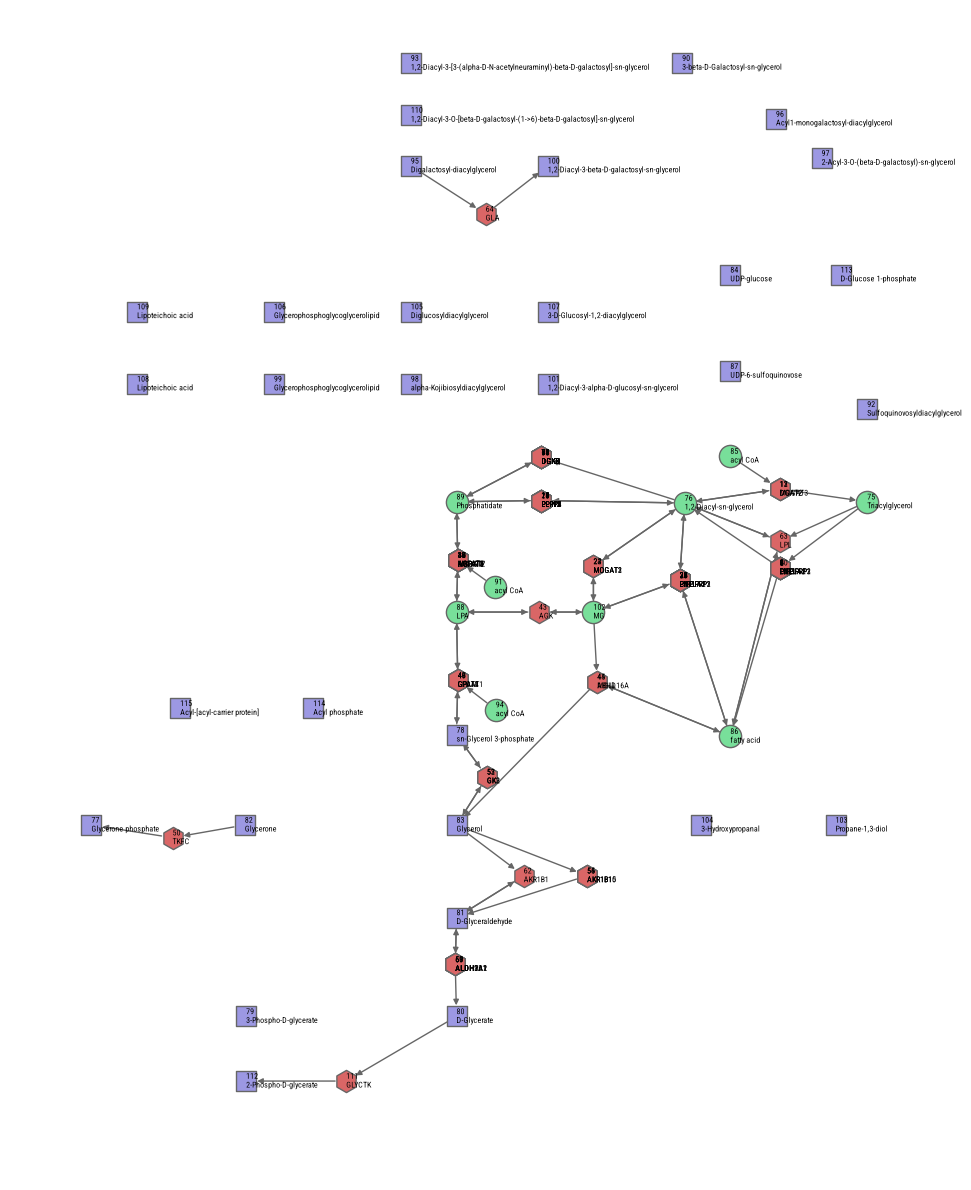

In [8]:
manager.reconnect()
pathway = load_pathway(manager, 1)
manager.close()
ax = plot_pathway_layout(
    pathway, 
    label_font_family="Roboto Condensed", 
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    },
    
)

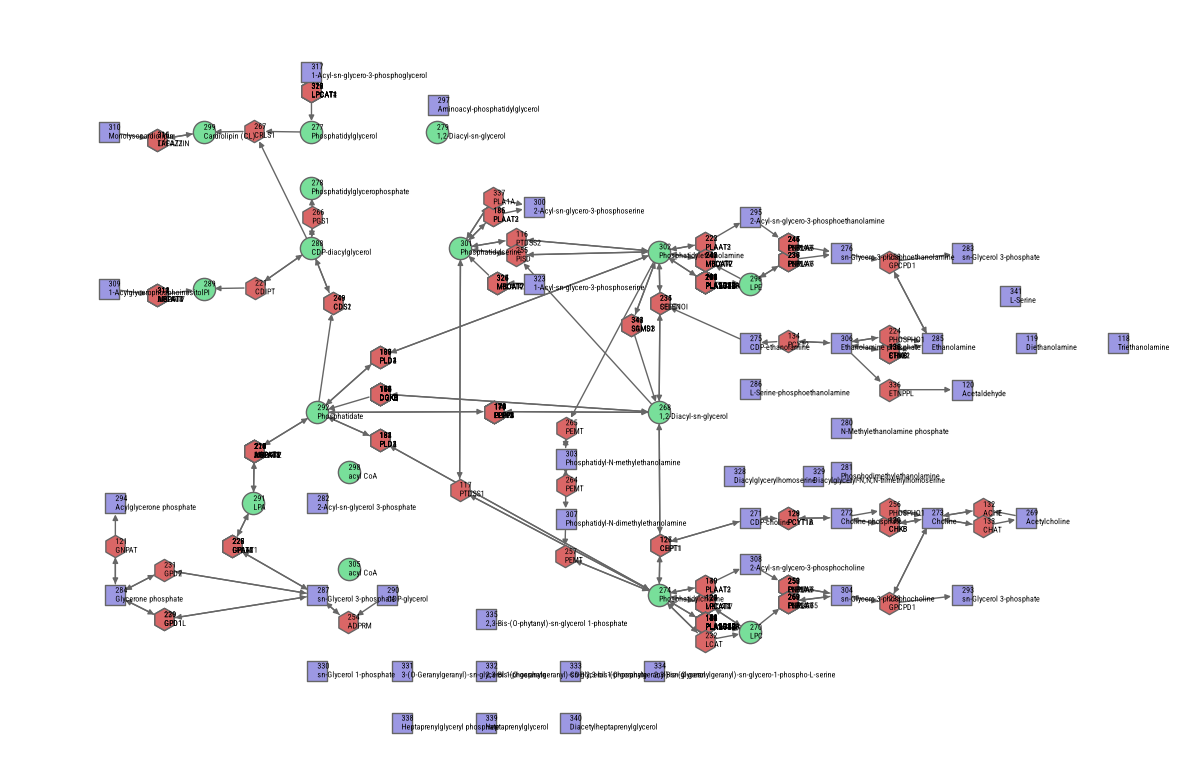

In [9]:
manager.reconnect()
pathway = load_pathway(manager, 2)
manager.close()
ax = plot_pathway_layout(
    pathway, 
    label_font_family="Roboto Condensed", 
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    }
)

In [10]:
manager.reconnect()
pathway = nx.compose(
    load_pathway(manager, 1),
    load_pathway(manager, 2),
)
manager.close()
pathway.remove_nodes_from(nx.isolates(pathway.copy()))

In [11]:
# relax the original layout with an iteration of spring layout
# holding the lipid group nodes in fixed positions
pos = nx.spring_layout(
    pathway, 
    k=0.5,
    gravity=10,
    iterations=1,
    pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    },
    fixed=[
        n
        for n, d in pathway.nodes(data=True)
        if d["type"] in ["LIPID_GROUP", "METABOLITE"]
    ]
)

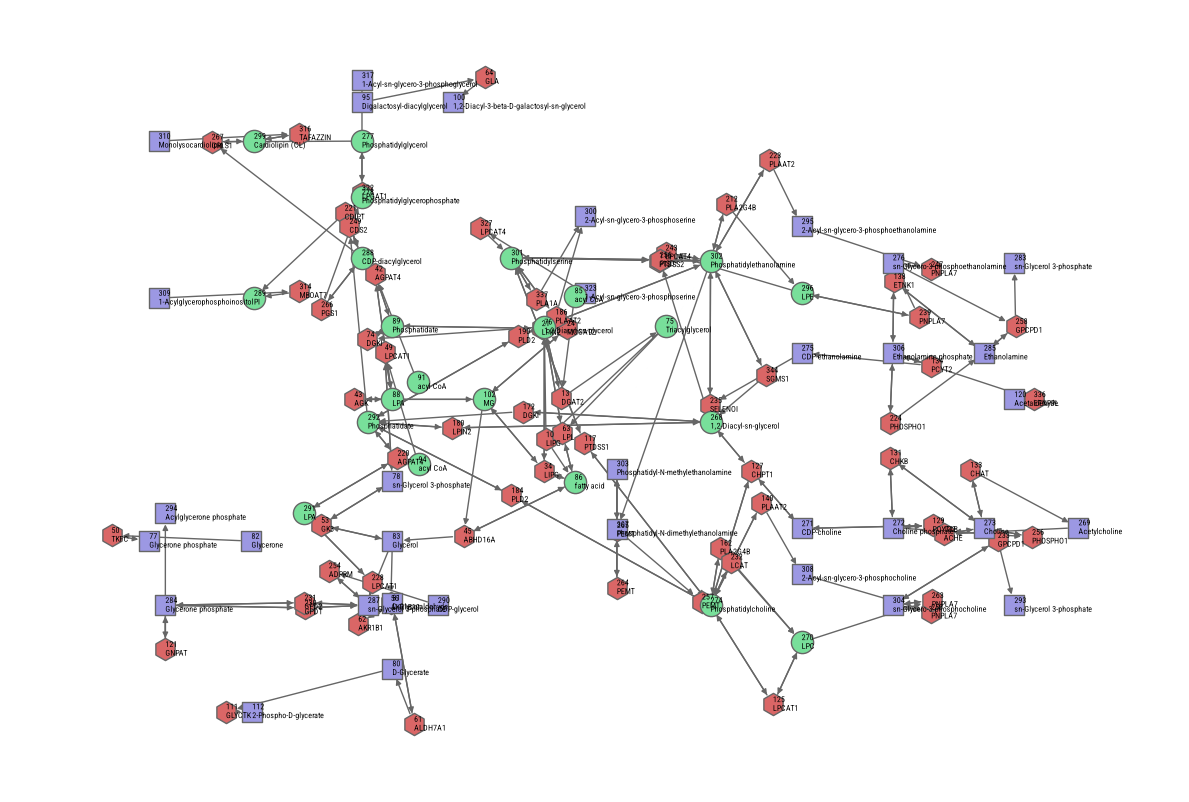

In [12]:
ax = plot_pathway_layout(
    pathway, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "full_pathway_layout.png"),
    node_pos=pos
)

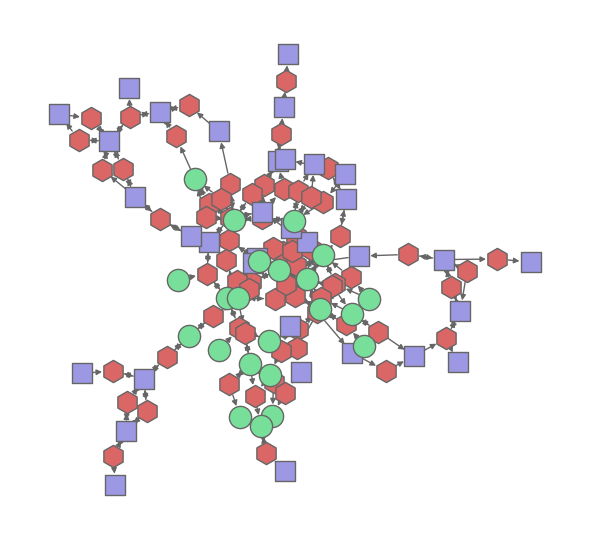

In [13]:
ax = plot_pathway_layout(
    pathway, 
    figsize=(6, 6), 
    add_labels=False, 
    figname=os.path.join(FIG_DIR, "full_pathway_layout_no-labels.png")
)

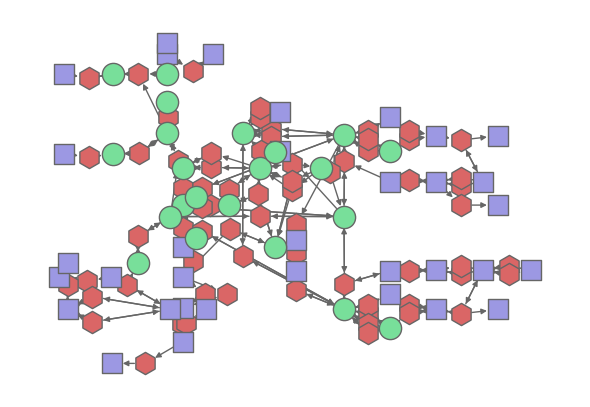

In [14]:
ax = plot_pathway_layout(
    pathway, 
    figsize=(6, 6), 
    add_labels=False, 
    figname=os.path.join(FIG_DIR, "full_pathway_layout_no-labels_alt-layout.png"),
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    }
)

In [15]:
# map transcriptomics data onto the pathway

# load the identifiers and statistics from input CSV
igroups, stats = load_stats_from_csv(
    TX_FILE,
    stat_type="log2(fold-change)",
    group_comparison="primitive vs. committed"
)

# map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "transcriptomics",
    igroups,
    stats
)

In [16]:
# map proteomics data onto the pathway

# load the identifiers and statistics from input CSV
igroups, stats = load_stats_from_csv(
    PX_FILE,
    stat_type="log2(fold-change)",
    group_comparison="primitive vs. committed"
)

# map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "proteomics",
    igroups,
    stats
)

In [17]:
# map metabolomics data onto the pathway

# load the identifiers and statistics from input CSV
igroups, stats = load_stats_from_csv(
    MX_FILE,
    stat_type="log2(fold-change)",
    group_comparison="primitive vs. committed"
)

# map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "metabolomics",
    igroups,
    stats
)

In [18]:
# map lipidomics data onto the pathway

# load the identifiers and statistics from input CSV
igroups, stats = load_stats_from_csv(
    LX_FILE,
    stat_type="log2(fold-change)",
    group_comparison="primitive vs. committed"
)

# map data onto the pathway
map_omics_data_to_pathway(
    pathway,
    "lipidomics",
    igroups,
    stats
)

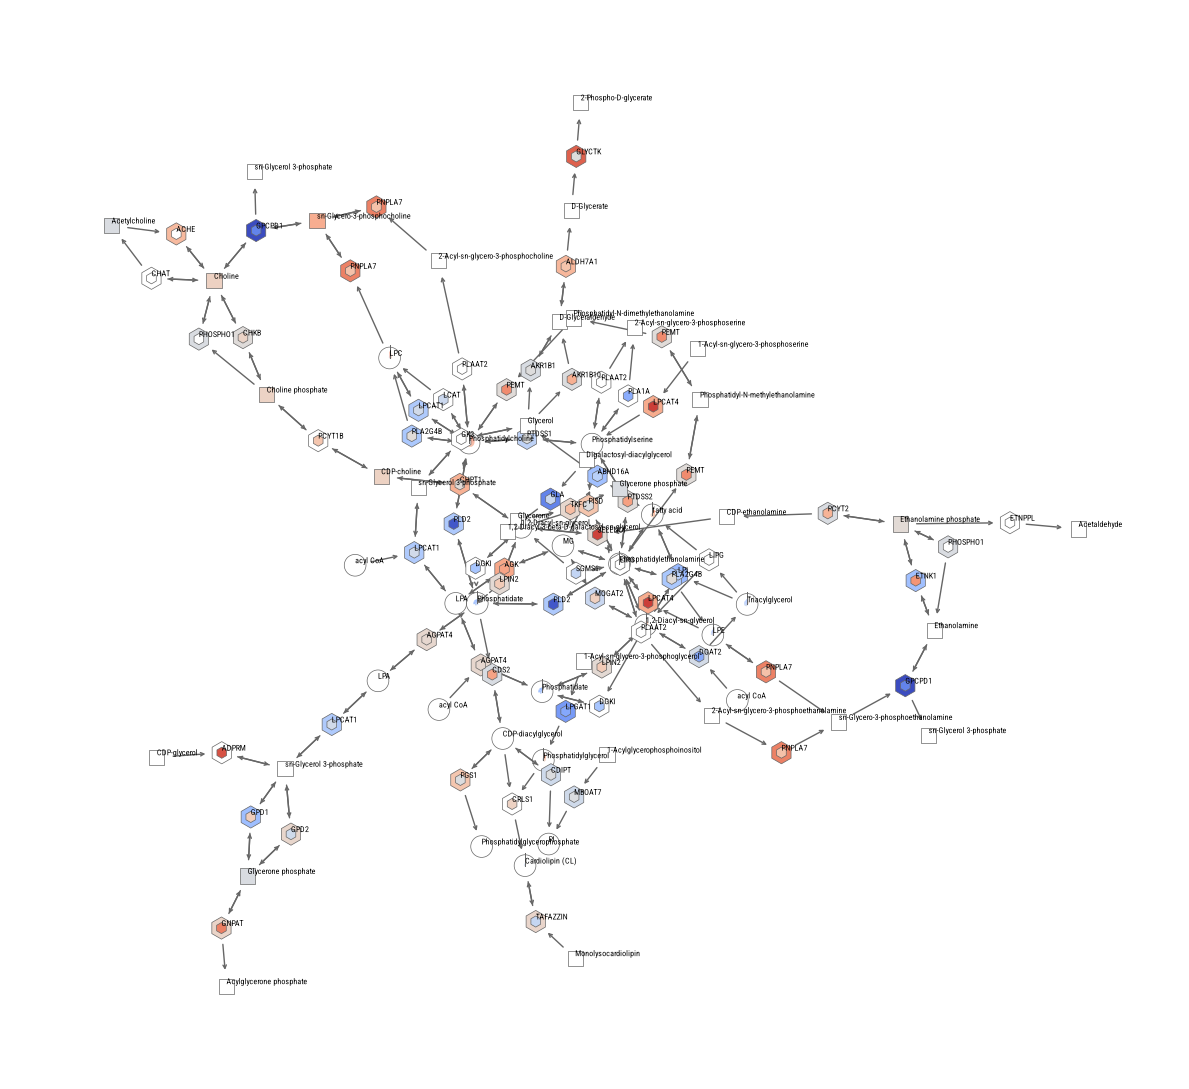

In [19]:
ax = plot_pathway_stats(
    pathway, 
    scale_radius=True,
    lipid_pie_r=0.02,
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "full_pathway_stats.png")
)

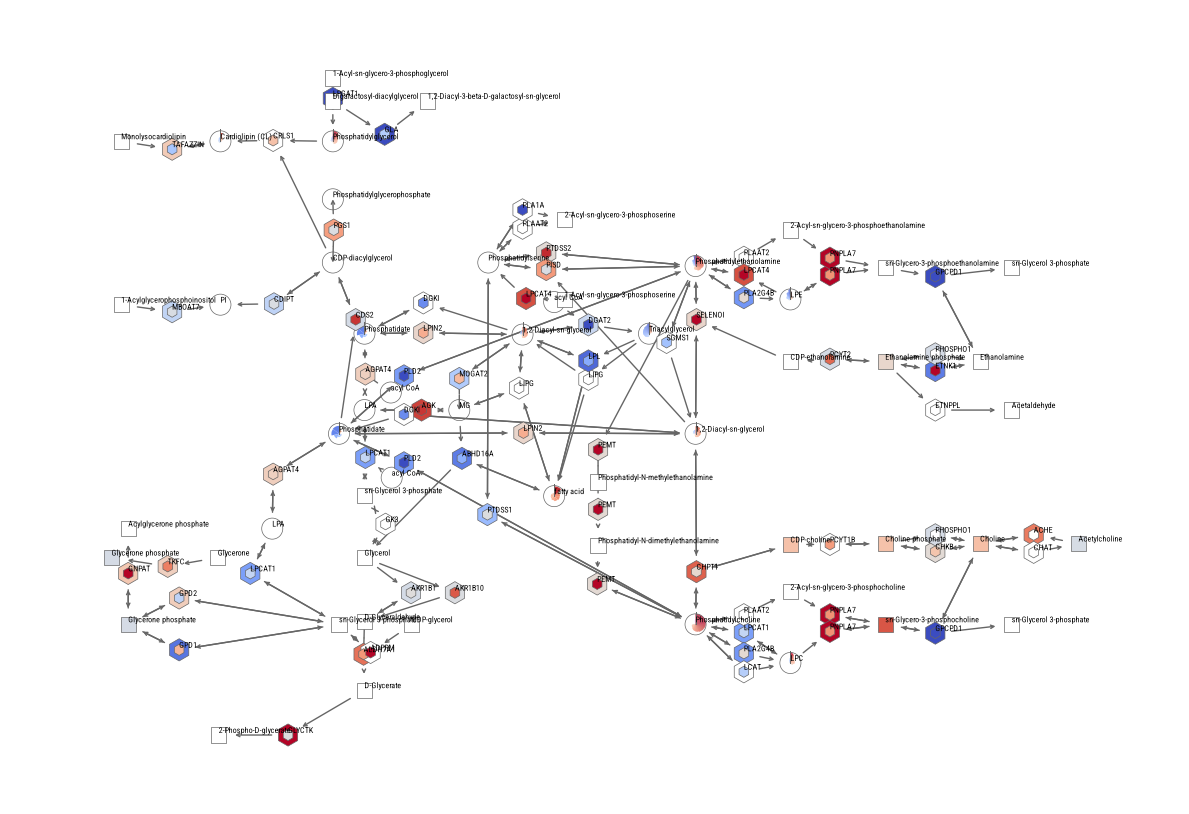

In [32]:
ax = plot_pathway_stats(
    pathway, 
    label_font_family="Roboto Condensed", 
    scale_radius=True, 
    lipid_pie_r=12,
    figname=os.path.join(FIG_DIR, "full_pathway_stats_alt-layout.pdf"),
    node_pos={
        n: (d["x"], d["y"])
        for n, d in pathway.nodes(data=True)
    },
    vmin=-0.5, 
    vmax=0.5
)

In [21]:
# select out a subset of nodes that includes 
# the direct connections between: 
#   PC (node_id=274)
#   PE (node_id=302)
#   DG (node_id=76)
#   TG (node_id=75)
subset_targets = {274, 302, 268, 75}
subset = pathway.subgraph(
    subset_targets
    | set(itertools.chain.from_iterable([
        itertools.chain.from_iterable(nx.all_simple_paths(pathway, a, b, cutoff=3))
        for a, b in itertools.combinations_with_replacement(subset_targets, 2)
    ]))
).copy()

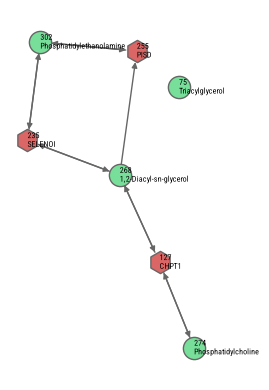

In [22]:
ax = plot_pathway_layout(
    subset, 
    label_font_family="Roboto Condensed", 
    figsize=(4, 4), 
    figname=os.path.join(FIG_DIR, "subset_layout.png")
)

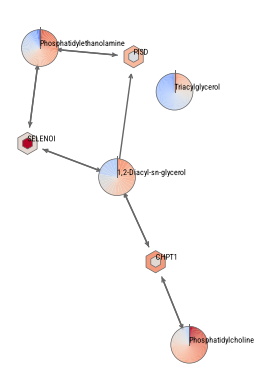

In [23]:
ax = plot_pathway_stats(
    subset, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_family="Roboto Condensed", 
    figsize=(4, 4), 
    figname=os.path.join(FIG_DIR, "subset_stats.png"),
    lipid_pie_r=0.1
)

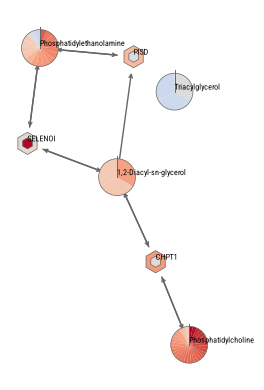

In [30]:
ax = plot_pathway_stats(
    subset, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_family="Roboto Condensed", 
    figsize=(4, 4), 
    contains_fas=[(20, 4)], 
    figname=os.path.join(FIG_DIR, "subset_stats_20-4.png"),
    lipid_pie_r=0.1
)

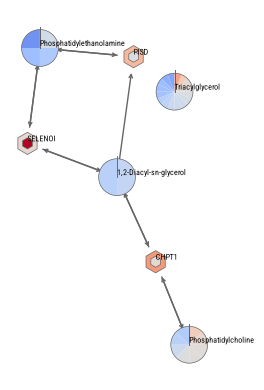

In [31]:
ax = plot_pathway_stats(
    subset, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_family="Roboto Condensed", 
    figsize=(4, 4), 
    contains_fas=[(22, 6)], 
    figname=os.path.join(FIG_DIR, "subset_stats_22-6.png"),
    lipid_pie_r=0.1
)

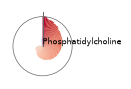

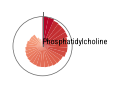

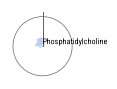

In [26]:
# PC
ax = plot_pathway_stats(
    pathway.subgraph({274}).copy(), 
    figsize=(1.5, 1.), 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75
)
ax = plot_pathway_stats(
    pathway.subgraph({274}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(20, 4)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "PC_20-4.png")
)
ax = plot_pathway_stats(
    pathway.subgraph({274}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(22, 6)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "PC_22-6.png")
)

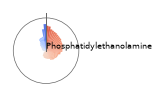

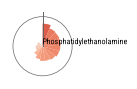

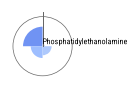

In [27]:
# PE
ax = plot_pathway_stats(
    pathway.subgraph({302}).copy(), 
    figsize=(1.5, 2.5), 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75
)
ax = plot_pathway_stats(
    pathway.subgraph({302}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(20, 4)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "PE_20-4.png")
)
ax = plot_pathway_stats(
    pathway.subgraph({302}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(22, 6)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "PE_22-6.png")
)

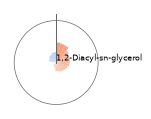

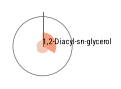

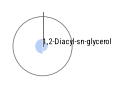

In [28]:
# DG
ax = plot_pathway_stats(
    pathway.subgraph({76}).copy(), 
    figsize=(1.5, 2.5), 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75
)
ax = plot_pathway_stats(
    pathway.subgraph({76}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(20, 4)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed",
    figname=os.path.join(FIG_DIR, "DG_20-4.png")
)
ax = plot_pathway_stats(
    pathway.subgraph({76}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(22, 6)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "DG_22-6.png")
)

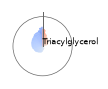

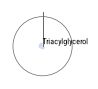

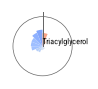

In [29]:
# TG
ax = plot_pathway_stats(
    pathway.subgraph({75}).copy(), 
    figsize=(1.5, 1.), 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75
)
ax = plot_pathway_stats(
    pathway.subgraph({75}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(20, 4)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "TG_20-4.png")
)
ax = plot_pathway_stats(
    pathway.subgraph({75}).copy(), 
    figsize=(1.5, 1.), 
    contains_fas=[(22, 6)], 
    scale_radius=True, 
    vmin=-0.75, 
    vmax=0.75, 
    label_font_size=6, 
    label_font_family="Roboto Condensed", 
    figname=os.path.join(FIG_DIR, "TG_22-6.png")
)